# Nombre : Toaquiza Yajaira

# Ejercicio 1
Se desea aproximar la integral definida

$$
I = \int_{0}^{\pi} e^{-x^2/2}\,dx
$$

mediante fórmulas de **Newton–Cotes simples y compuestas**, y analizar el comportamiento del **error teórico** y del **error práctico** para distintos números de subintervalos:

$$
n = 10,\;20,\;50,\;100.
$$

La función integrando

$$
f(x) = e^{-x^2/2}
$$

es continua e infinitamente derivable en $[0,\pi]$, por lo que cumple las hipótesis necesarias para aplicar las fórmulas de Newton–Cotes.



## Newton–Cotes simple

**Trapecio simple**

$$
\int_a^b f(x)\,dx \approx \frac{b-a}{2}[f(a)+f(b)]
$$

Error teórico:

$$
E_T = -\frac{(b-a)^3}{12}f''(\xi), \quad \xi \in (a,b).
$$

**Simpson simple**

$$
\int_a^b f(x)\,dx \approx \frac{b-a}{6}\left[f(a)+4f\!\left(\frac{a+b}{2}\right)+f(b)\right]
$$

Error teórico:

$$
E_S = -\frac{(b-a)^5}{2880}f^{(4)}(\xi), \quad \xi \in (a,b).
$$

Estas fórmulas se aplican sobre todo el intervalo y no dependen de $n$.



## Newton–Cotes compuesto

Se divide el intervalo $[a,b]$ en $n$ subintervalos de ancho

$$
h = \frac{b-a}{n}.
$$

**Trapecio compuesto**

$$
I_T = h\left[\frac{f(x_0)+f(x_n)}{2}+\sum_{i=1}^{n-1} f(x_i)\right]
$$

Error teórico:
$$
|E_T| \le \frac{(b-a)}{12}h^2 \max |f''(x)|.
$$

**Simpson compuesto** (n par)

$$
I_S = \frac{h}{3}\left[f(x_0)+f(x_n)
+4\sum_{\text{impares}} f(x_i)
+2\sum_{\text{pares}} f(x_i)\right]
$$

Error teórico:

$$
|E_S| \le \frac{(b-a)}{180}h^4 \max |f^{(4)}(x)|.
$$


Valor Exacto (Referencia): 1.2512081731

n     | Trapecio     | Error Trap   | Simpson      | Error Simp  
-----------------------------------------------------------------
10    | 1.25102443 | 1.84e-04   | 1.25119999 | 8.18e-06
20    | 1.25116185 | 4.63e-05   | 1.25120765 | 5.22e-07
30    | 1.25118755 | 2.06e-05   | 1.25120807 | 1.03e-07
40    | 1.25119657 | 1.16e-05   | 1.25120814 | 3.28e-08
50    | 1.25120074 | 7.43e-06   | 1.25120816 | 1.34e-08
60    | 1.25120301 | 5.16e-06   | 1.25120817 | 6.48e-09
70    | 1.25120438 | 3.79e-06   | 1.25120817 | 3.50e-09
80    | 1.25120527 | 2.90e-06   | 1.25120817 | 2.05e-09
90    | 1.25120588 | 2.29e-06   | 1.25120817 | 1.28e-09
100   | 1.25120632 | 1.86e-06   | 1.25120817 | 8.40e-10


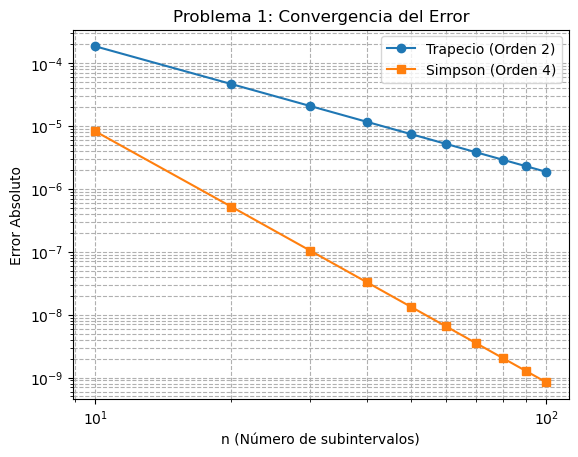

In [30]:
import numpy as np
from math import pi
from scipy.integrate import quad
from scipy import integrate
def f1(x):
    return np.exp(-(x**2)/2)

a, b = 0, np.pi
valor_exacto, _ = integrate.quad(f1, a, b)
print(f"Valor Exacto (Referencia): {valor_exacto:.10f}\n")

# 2. Implementación de Algoritmos
def metodo_trapecio(f, a, b, n):
    h = (b - a) / n
    suma = f(a) + f(b)
    for i in range(1, n):
        suma += 2 * f(a + i*h)
    return (h / 2) * suma

def metodo_simpson(f, a, b, n):
    if n % 2 != 0: n += 1 # Ajuste paridad
    h = (b - a) / n
    suma = f(a) + f(b)
    for i in range(1, n):
        if i % 2 != 0: suma += 4 * f(a + i*h)
        else:          suma += 2 * f(a + i*h)
    return (h / 3) * suma

# 3. Cálculo de Errores
n_valores = range(10, 101, 10)
errores_trap = []
errores_simp = []

print(f"{'n':<5} | {'Trapecio':<12} | {'Error Trap':<12} | {'Simpson':<12} | {'Error Simp':<12}")
print("-" * 65)

for n in n_valores:
    v_t = metodo_trapecio(f1, a, b, n)
    v_s = metodo_simpson(f1, a, b, n)
    e_t = abs(valor_exacto - v_t)
    e_s = abs(valor_exacto - v_s)
    
    errores_trap.append(e_t)
    errores_simp.append(e_s)
    print(f"{n:<5} | {v_t:.8f} | {e_t:.2e}   | {v_s:.8f} | {e_s:.2e}")

# 4. Gráfica Log-Log
plt.figure()
plt.loglog(n_valores, errores_trap, 'o-', label='Trapecio (Orden 2)')
plt.loglog(n_valores, errores_simp, 's-', label='Simpson (Orden 4)')
plt.xlabel('n (Número de subintervalos)')
plt.ylabel('Error Absoluto')
plt.title('Problema 1: Convergencia del Error')
plt.legend()
plt.grid(True, which="both", linestyle="--")
plt.show()

## Análisis del error práctico

El error práctico se define como

$$
E_p = |I_{\text{aprox}} - I_{\text{ref}}|.
$$

A partir de los resultados numéricos se observa que:

- El **trapecio compuesto** presenta una disminución del error proporcional a $h^2$, es decir,

$$
E_T = O(h^2).
$$

- El **Simpson compuesto** presenta una disminución del error proporcional a $h^4$, es decir,

$$
E_S = O(h^4).
$$

Este comportamiento concuerda plenamente con las cotas teóricas del error.



## Conclusiones

1. El método de Simpson compuesto es considerablemente más preciso que el trapecio compuesto para la integral considerada.

2. El comportamiento del error práctico confirma los órdenes teóricos de convergencia:
$$
\text{Trapecio: } O(h^2), \qquad \text{Simpson: } O(h^4).
$$

3. Para funciones suaves como $e^{-x^2/2}$, Simpson compuesto alcanza alta precisión con pocos subintervalos.

4. El error teórico actúa como una cota superior conservadora, mientras que el error práctico refleja el desempeño real del método.

5. Desde el punto de vista de eficiencia numérica, Simpson compuesto resulta claramente superior al trapecio compuesto en este problema.


# Ejercicio 2
# Comparación de tiempos de ejecución (Newton–Cotes) para una integral

Se desea aproximar la integral

$$
I=\int_{0}^{1}\frac{\ln(1+x)}{x^2+1}\,dx
$$

y comparar **tiempo de ejecución** (y también precisión) de **4 algoritmos**:

1. Trapecio **simple**
2. Simpson **simple**
3. Trapecio **compuesto** con $n$ subintervalos
4. Simpson **compuesto** con $n$ subintervalos (requiere $n$ par)

Se usará un valor de referencia $I_{\text{ref}}$ calculado con alta precisión, y se define el error práctico:

$$
E_p=\left|I_{\text{aprox}}-I_{\text{ref}}\right|.
$$

Para el método compuesto se toma

$$
h=\frac{1-0}{n}=\frac{1}{n}.
$$

La comparación de tiempos se realiza midiendo el tiempo promedio por ejecución (en milisegundos) usando múltiples repeticiones.


In [14]:
pip install pandas 

  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/11.0 MB 9.1 MB/s eta 0:00:02
   ---------- ----------------------------- 2.9/11.0 MB 7.9 MB/s eta 0:00:02
   --------------- ------------------------ 4.2/11.0 MB 7.1 MB/s eta 0:00:01
   -------------------- ------------------- 5.5/11.0 MB 7.0 MB/s eta 0:00:01
   ------------------------ --------------- 6.8/11.0 MB 6.7 MB/s eta 0:00:01
   ---------------------------- ----------- 7.9/11.0 MB 6.5 MB/s eta 0:00:01
   -------------------------------- ------- 8.9/11.0 MB 6.3 MB/s eta 0:00:01
   ----------------------------------- ---- 9.7/11.0 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------  10.7/11.0 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 5.8 MB/s  0:00:01
Using cached pytz-2025.2-py2

In [15]:
import numpy as np
import pandas as pd
from math import log
from time import perf_counter
from scipy.integrate import quad


In [16]:
def f(x):
    # f(x) = ln(1+x)/(1+x^2), con extensión continua en x=0: f(0)=0
    x = np.asarray(x)
    return np.where(x == 0, 0.0, np.log1p(x) / (1.0 + x*x))


In [17]:
# Valor de referencia (alta precisión)
I_ref, _ = quad(lambda t: log(1+t)/(1+t*t), 0.0, 1.0, epsabs=1e-14, epsrel=1e-14)
I_ref


0.2721982612879502

In [18]:
def trapecio_simple(f, a, b):
    return (b - a) / 2.0 * (f(a) + f(b))

def simpson_simple(f, a, b):
    m = (a + b) / 2.0
    return (b - a) / 6.0 * (f(a) + 4.0*f(m) + f(b))

def trapecio_compuesto(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    return h * (0.5*y[0] + y[1:-1].sum() + 0.5*y[-1])

def simpson_compuesto(f, a, b, n):
    if n % 2 != 0:
        raise ValueError("n debe ser par para Simpson compuesto")
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    return (h/3.0) * (y[0] + y[-1] + 4.0*y[1:-1:2].sum() + 2.0*y[2:-2:2].sum())


In [19]:
def bench(func, args, repeats=5000):
    
    t0 = perf_counter()
    for _ in range(repeats):
        func(*args)
    t1 = perf_counter()
    return (t1 - t0) / repeats

a, b = 0.0, 1.0
ns = [10, 20, 50, 100]

rows = []

# Métodos "simples" no dependen de n, pero los reportamos junto a cada n para comparar en la misma tabla
# (mismo valor y mismo tiempo promedio).
for n in ns:
    # Aproximaciones
    I_ts = trapecio_simple(f, a, b)
    I_ss = simpson_simple(f, a, b)
    I_tc = trapecio_compuesto(f, a, b, n)
    I_sc = simpson_compuesto(f, a, b, n)

    # Errores prácticos
    e_ts = abs(I_ts - I_ref)
    e_ss = abs(I_ss - I_ref)
    e_tc = abs(I_tc - I_ref)
    e_sc = abs(I_sc - I_ref)

    # Repeticiones 
    rep_simple = 20000
    rep_comp = 5000 if n <= 20 else 2000 if n <= 50 else 1000

    # Tiempos promedio (ms)
    t_ts = 1e3 * bench(trapecio_simple, (f, a, b), repeats=rep_simple)
    t_ss = 1e3 * bench(simpson_simple, (f, a, b), repeats=rep_simple)
    t_tc = 1e3 * bench(trapecio_compuesto, (f, a, b, n), repeats=rep_comp)
    t_sc = 1e3 * bench(simpson_compuesto, (f, a, b, n), repeats=rep_comp)

    rows.append([n, I_ts, e_ts, t_ts, I_ss, e_ss, t_ss, I_tc, e_tc, t_tc, I_sc, e_sc, t_sc])

df = pd.DataFrame(rows, columns=[
    "n",
    "Trapecio simple", "Err(TS)", "Tiempo TS (ms)",
    "Simpson simple", "Err(SS)", "Tiempo SS (ms)",
    "Trapecio comp.", "Err(TC)", "Tiempo TC (ms)",
    "Simpson comp.", "Err(SC)", "Tiempo SC (ms)"
])


df


,n,Trapecio simple,Err(TS),Tiempo TS (ms),Simpson simple,Err(SS),Tiempo SS (ms),Trapecio comp.,Err(TC),Tiempo TC (ms),Simpson comp.,Err(SC),Tiempo SC (ms)
0,10,0.173287,0.098911,0.005662,0.27401,0.001812,0.009386,0.271284,0.000915,0.007570,0.272201,2.984446e-06,0.008747
1,20,0.173287,0.098911,0.005641,0.27401,0.001812,0.009380,0.271970,0.000228,0.007679,0.272198,1.833194e-07,0.008793
2,50,0.173287,0.098911,0.005688,0.27401,0.001812,0.009421,0.272162,0.000037,0.008005,0.272198,4.670844e-09,0.008997
3,100,0.173287,0.098911,0.005644,0.27401,0.001812,0.009266,0.272189,0.000009,0.008320,0.272198,2.917319e-10,0.009183


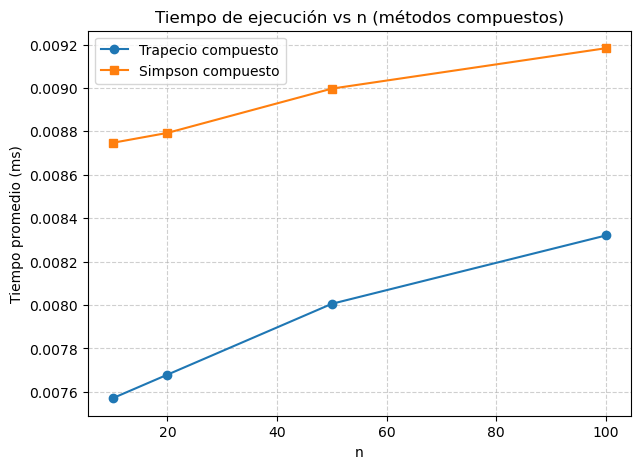

In [21]:
import matplotlib.pyplot as plt
n_vals = df["n"].to_numpy()

t_tc = df["Tiempo TC (ms)"].to_numpy()
t_sc = df["Tiempo SC (ms)"].to_numpy()

e_tc = df["Err(TC)"].to_numpy()
e_sc = df["Err(SC)"].to_numpy()

plt.figure(figsize=(7,5))
plt.plot(n_vals, t_tc, marker="o", label="Trapecio compuesto")
plt.plot(n_vals, t_sc, marker="s", label="Simpson compuesto")
plt.xlabel("n")
plt.ylabel("Tiempo promedio (ms)")
plt.title("Tiempo de ejecución vs n (métodos compuestos)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


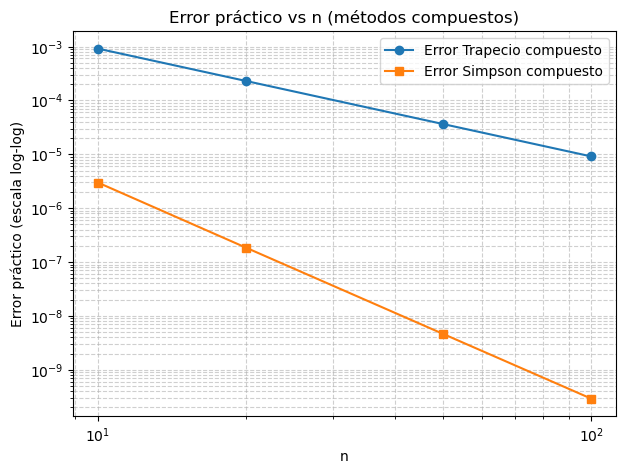

In [22]:
plt.figure(figsize=(7,5))
plt.loglog(n_vals, e_tc, marker="o", label="Error Trapecio compuesto")
plt.loglog(n_vals, e_sc, marker="s", label="Error Simpson compuesto")
plt.xlabel("n")
plt.ylabel("Error práctico (escala log-log)")
plt.title("Error práctico vs n (métodos compuestos)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.show()


## Conclusiones

1. **Métodos simples (Trapecio simple y Simpson simple):**  
   Su costo computacional es prácticamente constante (muy bajo), porque usan solo **2** y **3** evaluaciones de la función, respectivamente. Sin embargo, su **precisión es limitada**, pues aproximan en todo el intervalo con una sola “pieza”.

2. **Métodos compuestos:**  
   A medida que aumenta $n$, el tiempo de ejecución aumenta porque se evalúa la función en una malla de $n+1$ puntos. En general, el costo computacional crece aproximadamente de forma proporcional a $n$ (por el uso de sumas sobre la partición).

3. **Relación precisión–costo (lo más importante):**  
   - El **Trapecio compuesto** mejora la precisión al aumentar $n$, pero típicamente requiere valores más grandes de $n$ para alcanzar errores pequeños.  
   - El **Simpson compuesto** alcanza errores mucho menores con el mismo $n$, ya que su orden de convergencia es superior.

4. **Elección recomendada en la práctica:**  
   Si se busca un equilibrio entre **precisión alta** y **tiempo moderado**, el método de **Simpson compuesto** suele ser la mejor opción para integrandos suaves como

$$
\frac{\ln(1+x)}{1+x^2}.
$$

5. **Conclusión final:**  
   - Para cálculos rápidos con baja exigencia de precisión: **métodos simples**.  
   - Para precisión confiable con buen rendimiento: **Simpson compuesto** domina al trapecio compuesto en este problema.


# Ejercicio 3 
# Método de Euler explícito e implícito para una EDO lineal

Se considera la EDO:

$$
\begin{cases}
y'(x) + y(x) = \sin(x), \quad x\in[0,1)\\
y(0)=0
\end{cases}
$$

## Solución exacta

Reescribiendo:

$$
y'(x)=\sin(x)-y(x).
$$

Es una EDO lineal de primer orden. Con factor integrante:

$$
y'(x)+y(x)=\sin(x),\qquad \mu(x)=e^{x}.
$$

Entonces

$$
\frac{d}{dx}\big(e^x y(x)\big)=e^x\sin(x).
$$

Integrando de $0$ a $x$ y usando $y(0)=0$:

$$
e^x y(x)=\int_0^x e^t\sin(t)\,dt.
$$

Se conoce que

$$
\int e^t\sin(t)\,dt=\frac{e^t}{2}\big(\sin(t)-\cos(t)\big)+C.
$$

Por tanto,

$$
\int_0^x e^t\sin(t)\,dt=\frac{e^x}{2}\big(\sin(x)-\cos(x)\big)+\frac{1}{2}.
$$

Finalmente,

$$
y_{\text{exacta}}(x)=\frac{1}{2}\Big(\sin(x)-\cos(x)+e^{-x}\Big).
$$



## Métodos numéricos

Sea una partición uniforme con $n$ subintervalos en $[0,1]$:

$$
h=\frac{1-0}{n}=\frac{1}{n},\qquad x_k=kh,\quad k=0,1,\dots,n.
$$

### Euler explícito

Aplicado a $y'=\sin(x)-y$:

$$
y_{k+1}=y_k+h\big(\sin(x_k)-y_k\big)
=(1-h)y_k+h\sin(x_k).
$$

### Euler implícito

$$
y_{k+1}=y_k+h\big(\sin(x_{k+1})-y_{k+1}\big).
$$

Despejando $y_{k+1}$:

$$
(1+h)y_{k+1}=y_k+h\sin(x_{k+1})
\quad\Rightarrow\quad
y_{k+1}=\frac{y_k+h\sin(x_{k+1})}{1+h}.
$$

Se compararán los resultados con la solución exacta para:

$$
n=10,\;50,\;80.
$$


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def y_exact(x):
    return 0.5*(np.sin(x) - np.cos(x) + np.exp(-x))

def euler_explicito(n):
    a, b = 0.0, 1.0
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = np.zeros(n+1)
    y[0] = 0.0
    for k in range(n):
        y[k+1] = (1 - h)*y[k] + h*np.sin(x[k])
    return x, y

def euler_implicito(n):
    a, b = 0.0, 1.0
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = np.zeros(n+1)
    y[0] = 0.0
    for k in range(n):
        y[k+1] = (y[k] + h*np.sin(x[k+1])) / (1 + h)
    return x, y


In [24]:
def resumen_errores(n_list):
    rows = []
    for n in n_list:
        xE, yE = euler_explicito(n)
        xI, yI = euler_implicito(n)
        yex = y_exact(xE)

        errE = np.abs(yE - yex)
        errI = np.abs(yI - yex)

        rows.append({
            "n": n,
            "h": 1.0/n,
            "Max error Euler explícito": errE.max(),
            "Max error Euler implícito": errI.max(),
            "Error en x=1 (explícito)": abs(yE[-1] - yex[-1]),
            "Error en x=1 (implícito)": abs(yI[-1] - yex[-1]),
        })
    return pd.DataFrame(rows)

df_err = resumen_errores([10, 50, 80])
df_err


,n,h,Max error Euler explícito,Max error Euler implícito,Error en x=1 (explícito),Error en x=1 (implícito)
0,10,0.1000,0.016352,0.014554,0.014330,0.012774
1,50,0.0200,0.003116,0.003044,0.002733,0.002671
2,80,0.0125,0.001939,0.001911,0.001701,0.001676


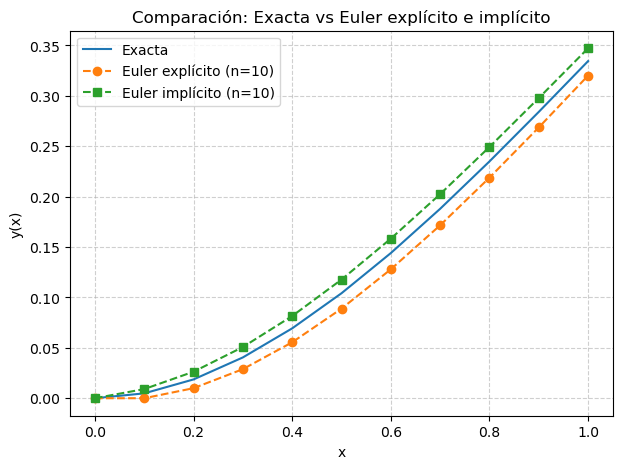

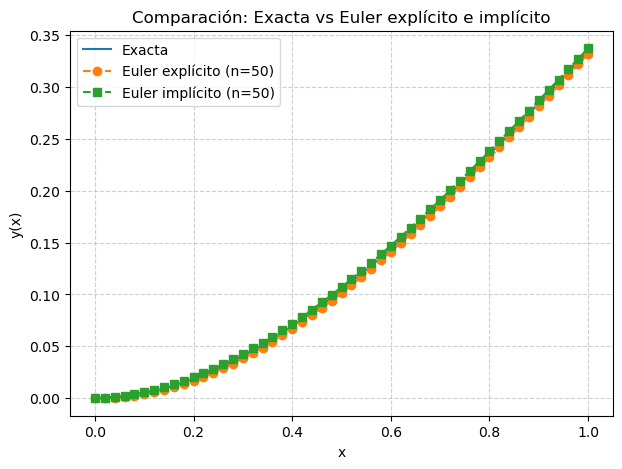

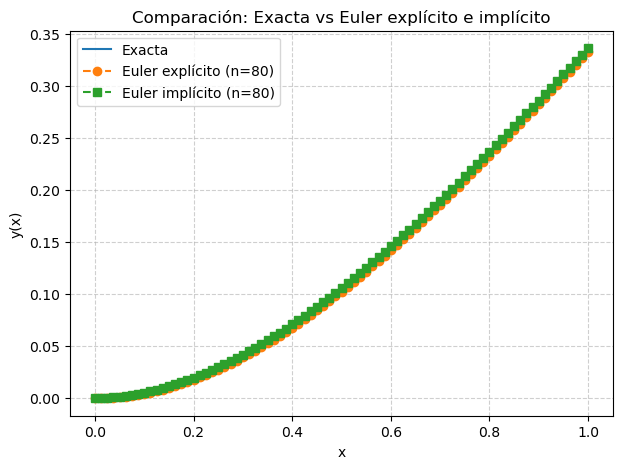

In [25]:
n_list = [10, 50, 80]

for n in n_list:
    x, yE = euler_explicito(n)
    _, yI = euler_implicito(n)
    yex = y_exact(x)

    plt.figure(figsize=(7,5))
    plt.plot(x, yex, label="Exacta")
    plt.plot(x, yE, marker="o", linestyle="--", label=f"Euler explícito (n={n})")
    plt.plot(x, yI, marker="s", linestyle="--", label=f"Euler implícito (n={n})")
    plt.xlabel("x")
    plt.ylabel("y(x)")
    plt.title("Comparación: Exacta vs Euler explícito e implícito")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()


## Comentarios y conclusiones

1. Ambos métodos (Euler explícito e implícito) son de **orden 1**, por lo que se espera que el error decrezca aproximadamente de forma proporcional a $h$:

$$
E = O(h).
$$

2. Al aumentar $n$ (disminuir $h$), los errores máximos y los errores en $x=1$ deben disminuir, lo cual se verifica con la tabla de errores.

3. El método de Euler implícito tiende a ser más **estable** en problemas rígidos. En esta EDO particular (lineal, suave y no rígida en $[0,1]$), ambos métodos muestran un comportamiento estable y convergente.

4. La comparación gráfica muestra que, a medida que $n$ crece, las aproximaciones numéricas se acercan a la solución exacta en todo el intervalo.

5. Para propósitos prácticos en esta EDO, con $n=50$ o $n=80$ ambos métodos proporcionan aproximaciones notablemente más cercanas a la exacta que con $n=10$.
